# Predicting Unusual Household and Housing Profiles Related to Social Tenancy Risk Using Machine Learning
Ahmed Zaus Zahid, Afnan Ali, Aminath Iuzaaz Ismail



### Loading the data
The AHS dataset is a massive dataset. However, most of the data is not related to our specific usecase and we will not be needing them. Before we can train our models on the data, we need to identify which columns we need and treat the data which requires cleaning. 

In [171]:
import pandas as pd

# the columns we need from the dataset
ahs_cols = [
    "CONTROL", "TENURE", "WEIGHT",
    "HUDSUB", "RENTSUB", "RENTCNTRL",
    "HINCP", "FINCP", "PERPOVLVL", "FS",
    "NUMPEOPLE", "BEDROOMS", "TOTROOMS",
    "NUMADULTS", "NUMELDERS", "NUMYNGKIDS", "NUMOLDKIDS", "UNITSIZE",
    "RENT", "TOTHCAMT", "UTILAMT",
    "HIAFFORD", "HIBEHINDFRQ", "HIHALF", "HINUMOVE",
    "HIEVICNOTE", "HIEVICTHT", "HIEVICLK", "HINOWHERE",
    "MGRONSITE",
    "NUMNONREL", "NUMSECFAM", "NUMSUBFAM",
    "OCCJANUR", "OCCFEBRU", "OCCMARCH", "OCCAPRIL", "OCCMAY", "OCCJUNE",
    "OCCJULY", "OCCAUGUST", "OCCSEPTEM", "OCCOCTOB", "OCCNOVEM", "OCCDECEM",
    "OCCYRRND", "MONLSTOCC", "VACMONTHS",
]

df = pd.read_csv(
    "household.csv",             # AHS 2023 national PUF file
    quotechar="'",               # strips the single quotes around every value
    usecols=lambda c: c in ahs_cols,   # only load these columns
)


print(df.shape)
print(df.head())

(55669, 48)
    CONTROL  TOTROOMS  PERPOVLVL  RENT  TENURE  HIEVICLK  HIAFFORD  HIHALF  \
0  11000002         6         -6  1600      -6        -6        -6      -6   
1  11000003         4        199   840       2         4         4       2   
2  11000005         7        501    -6       1        -6        -6      -6   
3  11000006         5        232    -6       1        -6        -6      -6   
4  11000008         3        231   800       2         2         2       1   

   OCCJANUR  OCCFEBRU  ...  HIBEHINDFRQ  HINOWHERE  HIEVICTHT  HIEVICNOTE  \
0         1         1  ...           -6         -6         -6          -6   
1        -6        -6  ...            6          0          2          -6   
2        -6        -6  ...           -6          0         -6          -6   
3        -6        -6  ...           -6         -6         -6          -6   
4        -6        -6  ...            2          0          1           1   

   HINUMOVE  MGRONSITE  HUDSUB   HINCP   FINCP  TOTHCAMT

Running the cell, we can already see that our data needs cleaning even though the printed section is only a small slice of the full data. The AHS dataset uses -6 and -9 to represent Null values.

### Analysing the data for cleaning

In [172]:
r = df[df["TENURE"] == 2].replace([-6, -9], pd.NA)   # renters only, codes -> NaN
missing = r.isna().mean().sort_values(ascending=False)
print((missing * 100).round(1))
print("renter rows:", len(r))

OCCAUGUST      100.0
OCCJULY        100.0
OCCJUNE        100.0
OCCMAY         100.0
OCCAPRIL       100.0
OCCMARCH       100.0
OCCFEBRU       100.0
OCCJANUR       100.0
OCCDECEM       100.0
VACMONTHS      100.0
MONLSTOCC      100.0
OCCYRRND       100.0
OCCOCTOB       100.0
OCCNOVEM       100.0
OCCSEPTEM      100.0
HIEVICNOTE      98.1
RENTCNTRL       87.6
HIHALF          52.6
HIEVICLK        51.7
HIAFFORD        51.7
HIBEHINDFRQ     51.6
HINOWHERE       51.6
HIEVICTHT       51.5
HINUMOVE        50.7
MGRONSITE       31.0
FS              30.0
UNITSIZE        18.0
RENTSUB          2.0
TENURE           0.0
PERPOVLVL        0.0
TOTROOMS         0.0
CONTROL          0.0
RENT             0.0
NUMSUBFAM        0.0
NUMOLDKIDS       0.0
NUMYNGKIDS       0.0
NUMNONREL        0.0
NUMADULTS        0.0
NUMELDERS        0.0
WEIGHT           0.0
NUMSECFAM        0.0
UTILAMT          0.0
NUMPEOPLE        0.0
BEDROOMS         0.0
HUDSUB           0.0
HINCP            0.0
FINCP            0.0
TOTHCAMT     

Filtering by TENURE == 2 (rented) and checking for missing data values per column. We have to drop all the columns without enough data. Columns that have 50% missing data can be considered, however we will ignore those for now and come back to it if the model requires more signals.

### Updated columns after removing columns with missing data

In [173]:
KEEP_COLS = [
    "CONTROL", "TENURE", "WEIGHT",
    "HUDSUB", "RENTSUB", "RENTCNTRL", "HHMOVE",
    "HINCP", "FINCP", "PERPOVLVL", "FS",
    "NUMPEOPLE", "BEDROOMS", "TOTROOMS",
    "NUMADULTS", "NUMELDERS", "NUMYNGKIDS", "NUMOLDKIDS", "UNITSIZE",
    "RENT", "TOTHCAMT", "UTILAMT",
    "MGRONSITE",
    "NUMNONREL", "NUMSECFAM", "NUMSUBFAM",
]

DROP_ALWAYS = (
    ["OCCJANUR", "OCCFEBRU", "OCCMARCH", "OCCAPRIL", "OCCMAY", "OCCJUNE",
     "OCCJULY", "OCCAUGUST", "OCCSEPTEM", "OCCOCTOB", "OCCNOVEM", "OCCDECEM",
     "OCCYRRND", "VACMONTHS", "MONLSTOCC"]        # 100% empty on renters
    + ["HIEVICNOTE"]                               # 98% empty (skip pattern)
    + ["HIAFFORD", "HIBEHINDFRQ", "HIHALF", "HINUMOVE",
       "HIEVICLK", "HIEVICTHT", "HINOWHERE"]       # ~50% (split-sample)
)

### Loading the data again

In [174]:
df = pd.read_csv(
    "household.csv",
    quotechar="'",
    usecols=lambda c: c in KEEP_COLS,
)
print(df.shape)
df.head()

(55669, 26)


,CONTROL,TOTROOMS,PERPOVLVL,RENT,TENURE,RENTCNTRL,RENTSUB,WEIGHT,HHMOVE,NUMELDERS,...,NUMPEOPLE,UNITSIZE,BEDROOMS,UTILAMT,FS,MGRONSITE,HUDSUB,HINCP,FINCP,TOTHCAMT
0,11000002,6,-6,1600,-6,-6,8,813.890194,-6,-6,...,-6,7,4,0,-6,-6,-6,-6,-6,-6
1,11000003,4,199,840,2,-6,8,581.103231,2023,0,...,3,-9,2,240,2,-6,3,48000,48000,1093
2,11000005,7,501,-6,1,-6,-6,7335.965001,1995,2,...,2,6,4,260,-6,-6,-6,292500,292500,810
3,11000006,5,232,-6,1,-6,-6,6562.865941,2019,0,...,3,4,3,270,2,-6,-6,56000,56000,489
4,11000008,3,231,800,2,-6,8,1490.800600,2019,0,...,1,-9,1,4,-6,4,3,36000,36000,845


### Replacing -6 and -9 with NA

In [175]:
df = df.replace([-6, -9], pd.NA)
df = df[df["TENURE"] == 2].copy()
print(f"{len(df)} renter rows")

19735 renter rows


### Dropping columns

In [176]:
df = df.drop(columns=[c for c in DROP_ALWAYS if c in df.columns])
print(f"{df.shape[1]} columns kept")

26 columns kept


### Recoding NA flags to 0

In [177]:
for col in ["RENTCNTRL", "MGRONSITE"]:
    df[col] = df[col].fillna(0)

In [178]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df.dtypes

CONTROL         int64
TOTROOMS        int64
PERPOVLVL       int64
RENT            int64
TENURE          int64
RENTCNTRL       int64
RENTSUB       float64
WEIGHT        float64
HHMOVE          int64
NUMELDERS       int64
NUMADULTS       int64
NUMNONREL       int64
NUMYNGKIDS      int64
NUMOLDKIDS      int64
NUMSUBFAM       int64
NUMSECFAM       int64
NUMPEOPLE       int64
UNITSIZE      float64
BEDROOMS        int64
UTILAMT         int64
FS            float64
MGRONSITE       int64
HUDSUB          int64
HINCP           int64
FINCP           int64
TOTHCAMT        int64
dtype: object

In [179]:
df["persons_per_room"] = df["NUMPEOPLE"] / df["TOTROOMS"]
df["is_crowded"] = (df["persons_per_room"] > 1).astype(int)
df["is_crowded"].value_counts()

is_crowded
0    19152
1      583
Name: count, dtype: int64

In [180]:
miss = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
miss[miss > 0]

FS          30.0
UNITSIZE    18.0
RENTSUB      2.0
dtype: float64

In [181]:
df = df.drop(columns=["UNITSIZE"])
df = df.drop(columns=["FS"])

In [182]:
# Restrict to subsidised households only — the actual "social housing" scope.
# Codes: 1 = public housing/multifamily, 2 = Housing Choice Voucher.
df = df[df["HUDSUB"].isin([1, 2])].copy()
print(f"{len(df)} subsidised households")

6270 subsidised households


In [183]:
# 1. Subsidy/eligibility anomaly: subsidised AND income high for need.
#    Everyone here is already subsidised (filtered above), so this is just
#    the income-eligibility part now.
df["flag_subsidy_anomaly"] = (df["PERPOVLVL"] > 200).astype(int)

# 2. Unrelated adults present (potential sub-tenants)
df["flag_unrelated"] = (df["NUMNONREL"] >= 2).astype(int)

# 3. Secondary / sub-family in one unit (subdivision into lets)
df["flag_secondary_family"] = (
    (df["NUMSECFAM"] >= 1) | (df["NUMSUBFAM"] >= 1)
).astype(int)

# 4. Overcrowding (already built during cleaning)
df["flag_crowded"] = df["is_crowded"]

# strong = any of the four substantive flags (used to gate recent-move)
strong = (
    df["flag_subsidy_anomaly"]
    + df["flag_unrelated"]
    + df["flag_secondary_family"]
    + df["flag_crowded"]
)

# 5. Recent move-in, but only counts when a strong flag is already firing
df["flag_recent_move"] = (df["HHMOVE"] >= 2022).astype(int)
df["flag_recent_move_adj"] = (
    (df["flag_recent_move"] == 1) & (strong >= 1)
).astype(int)

In [184]:
df["risk_score"] = (
    2 * df["flag_subsidy_anomaly"]
    + 2 * df["flag_unrelated"]
    + 2 * df["flag_secondary_family"]
    + 1 * df["flag_crowded"]
    + 1 * df["flag_recent_move_adj"]
)

def to_tier(s):
    if s == 0:  return "Low Concern"
    if s <= 2:  return "Monitor"
    if s <= 4:  return "Investigate"
    return "Priority Action"

df["risk_tier"] = df["risk_score"].apply(to_tier)

In [185]:
print(df[["flag_subsidy_anomaly", "flag_unrelated", "flag_secondary_family",
          "flag_crowded", "flag_recent_move_adj"]].sum())
print()
print(df["risk_tier"].value_counts())

flag_subsidy_anomaly     784
flag_unrelated            21
flag_secondary_family     85
flag_crowded              85
flag_recent_move_adj     141
dtype: int64

risk_tier
Low Concern        5350
Monitor             743
Investigate         168
Priority Action       9
Name: count, dtype: int64


In [186]:
def to_tier(s):
    if s == 0:  return "Low Concern"
    if s <= 2:  return "Monitor"
    return "High Concern"      # score 3+ (was Investigate + Priority)

df["risk_tier"] = df["risk_score"].apply(to_tier)
df["risk_tier"].value_counts()

risk_tier
Low Concern     5350
Monitor          743
High Concern     177
Name: count, dtype: int64

In [187]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline          # NOTE: imblearn's Pipeline, not sklearn's
from imblearn.over_sampling import SMOTE
import pandas as pd

In [188]:
# EXCLUDED because they ARE the label or directly build it — feeding these in
# would let the model reconstruct your rule and score a meaningless ~99%:
#   PERPOVLVL, HINCP, FINCP        -> build flag_subsidy_anomaly
#   NUMNONREL                      -> flag_unrelated
#   NUMSECFAM, NUMSUBFAM           -> flag_secondary_family
#   NUMPEOPLE, TOTROOMS,
#   is_crowded, persons_per_room   -> flag_crowded
#   HHMOVE                         -> flag_recent_move
#   all flag_*, risk_score         -> the label itself
#
# KEPT: cost / structure / subsidy-type / demographic signals that the rule
# never used. The model's real question becomes: can these predict the tier
# a household's composition earned?  (Honest, non-circular.)

feature_cols = [
    "HUDSUB",       # subsidy type (1 = public housing, 2 = voucher)
    "RENT",         # monthly rent
    "TOTHCAMT",     # total housing cost
    "UTILAMT",      # utilities
    "BEDROOMS",     # unit structure
    "MGRONSITE",    # on-site management
    "NUMADULTS", "NUMELDERS", "NUMYNGKIDS", "NUMOLDKIDS",  # household make-up
]

X = df[feature_cols].copy()
y = df["risk_tier"].copy()

X = X.fillna(X.median())        # cost/structure cols are ~complete; this is a safety net
print(X.shape)
print(y.value_counts())

(6270, 10)
risk_tier
Low Concern     5350
Monitor          743
High Concern     177
Name: count, dtype: int64


In [189]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print("train:", y_train.value_counts().to_dict())
print("test: ", y_test.value_counts().to_dict())

train: {'Low Concern': 4012, 'Monitor': 557, 'High Concern': 133}
test:  {'Low Concern': 1338, 'Monitor': 186, 'High Concern': 44}


In [190]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":        DecisionTreeClassifier(random_state=42),
    "Random Forest":        RandomForestClassifier(random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(random_state=42),
    "SVM":                  SVC(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in models.items():
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("smote", SMOTE(random_state=42)),   # runs on the training portion of each fold only
        ("clf",   clf),
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=["f1_macro", "f1_weighted"])
    macro = scores["test_f1_macro"].mean()
    weighted = scores["test_f1_weighted"].mean()
    print(f"{name:22s} macro-F1: {macro:.3f}   weighted-F1: {weighted:.3f}")

Logistic Regression    macro-F1: 0.411   weighted-F1: 0.737
Decision Tree          macro-F1: 0.396   weighted-F1: 0.751
Random Forest          macro-F1: 0.432   weighted-F1: 0.783
Gradient Boosting      macro-F1: 0.448   weighted-F1: 0.772
SVM                    macro-F1: 0.415   weighted-F1: 0.744


In [191]:
# pick whichever model won above; Random Forest is a sensible default
best = Pipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf",   GradientBoostingClassifier(random_state=42)),
]).fit(X_train, y_train)

y_pred = best.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred, labels=["Low Concern","Monitor","High Concern"]))


              precision    recall  f1-score   support

High Concern       0.10      0.18      0.13        44
 Low Concern       0.92      0.77      0.84      1338
     Monitor       0.26      0.51      0.34       186

    accuracy                           0.73      1568
   macro avg       0.43      0.49      0.44      1568
weighted avg       0.82      0.73      0.76      1568

[[1036  251   51]
 [  73   95   18]
 [  17   19    8]]


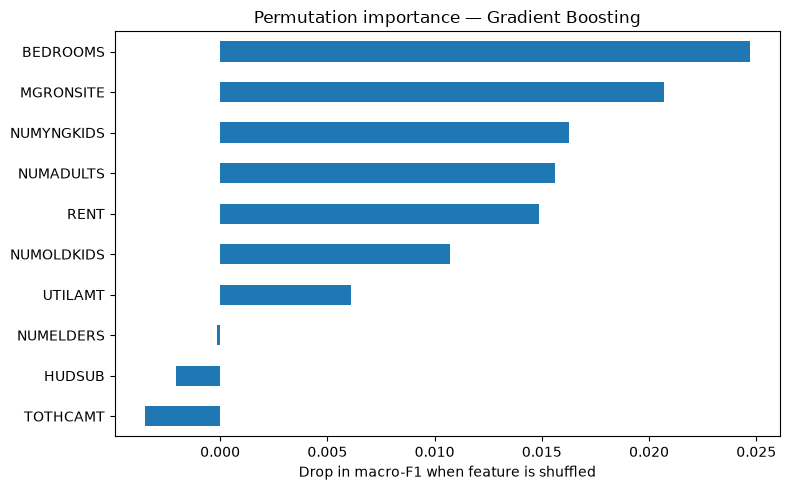

In [193]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

result = permutation_importance(
    best, X_test, y_test, scoring="f1_macro", n_repeats=20, random_state=42
)
imp = pd.Series(result.importances_mean, index=feature_cols).sort_values()

plt.figure(figsize=(8, 5))
imp.plot.barh()
plt.xlabel("Drop in macro-F1 when feature is shuffled")
plt.title("Permutation importance — Gradient Boosting")
plt.tight_layout(); plt.show()